# 07 — Positive EV board (research)

Ranks **observed** moneyline sides where B1 Overall Elo implies positive bettable EV:

`EV = model_p_wins * decimal(american) - 1`

**Not tips / not executable fills.** Model estimand is P(win | completes);
books may grade retirements differently. Prices are snapshots, not guaranteed offers.
Prefer **no bet** when names do not match, quotes are stale/suspended, or EV is below `MIN_EV`.

Requires `06` quotes at `data/raw/odds/quotes.parquet` (or set `COLLECT=True`) and
`data/processed/modeling.parquet`.


In [1]:
from __future__ import annotations

import os
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from tml.features.elo import OVERALL_SURFACE, EloState, update_tournament
from tml.models.elo_prob import elo_win_prob
from tml.odds.client import fetch_h2h
from tml.odds.storage import QuoteStore
from tml.shared.config import get_settings
from tml.shared.result import Err

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

os.chdir(REPO_ROOT)
get_settings.cache_clear()
settings = get_settings()

QUOTE_PATH = REPO_ROOT / "data" / "raw" / "odds" / "quotes.parquet"
store = QuoteStore(QUOTE_PATH)

MIN_EV = 0.0  # raise (e.g. 0.02) to require a larger edge
COLLECT = not store.path.exists()
SPORT_KEY = "tennis_atp"

print("repo", REPO_ROOT)
print("quotes", store.path, "exists", store.path.exists())
print("MIN_EV", MIN_EV, "COLLECT", COLLECT)


repo /Users/alexgonzalez/Documents/tennis moneyline predictions
quotes /Users/alexgonzalez/Documents/tennis moneyline predictions/data/raw/odds/quotes.parquet exists True
MIN_EV 0.0 COLLECT False


In [2]:
if COLLECT:
    result = fetch_h2h(SPORT_KEY)
    if isinstance(result, Err):
        raise RuntimeError(result.error)
    if not result.value:
        raise RuntimeError(f"no h2h quotes for {SPORT_KEY}")
    store.append(result.value)
    print(f"appended {len(result.value)} quotes")
elif not store.path.exists():
    raise FileNotFoundError(
        f"Missing {store.path}. Run notebook 06 or set COLLECT=True."
    )

quotes = [
    q
    for q in store.load()
    if not q.is_cancelled and not q.is_suspended and q.odds_format == "american"
]
print("usable quotes", len(quotes))


usable quotes 76


In [3]:
def _normalize_name(value: str) -> str:
    ascii_value = unicodedata.normalize("NFKD", value).encode("ascii", "ignore").decode()
    return " ".join(re.findall(r"[a-z0-9]+", ascii_value.casefold()))


def _american_to_decimal(price: float) -> float:
    if price >= 100:
        return 1.0 + price / 100.0
    if price <= -100:
        return 1.0 + 100.0 / abs(price)
    raise ValueError(f"invalid American price: {price}")


def _name_to_player_id(data_dir: Path) -> dict[str, str]:
    buckets: dict[str, set[str]] = {}
    files = [
        path
        for path in sorted(data_dir.glob("20*.csv"))
        if "wta" not in path.name.casefold() and "ranking" not in path.name.casefold()
    ]
    for path in files:
        try:
            frame = pd.read_csv(
                path,
                usecols=lambda c: c
                in {"winner_id", "loser_id", "winner_name", "loser_name"},
            )
        except (ValueError, OSError):
            continue
        for side in ("winner", "loser"):
            for player_id, name in zip(
                frame[f"{side}_id"].astype(str),
                frame[f"{side}_name"].astype(str),
                strict=True,
            ):
                buckets.setdefault(_normalize_name(name), set()).add(player_id)
    return {
        name: next(iter(ids)) for name, ids in buckets.items() if len(ids) == 1
    }


data_dir = Path(settings.tml_data_dir)
if not data_dir.exists():
    data_dir = REPO_ROOT / "notebooks" / "tml-data"
name_to_id = _name_to_player_id(data_dir)

matches = pd.read_parquet(REPO_ROOT / "data" / "processed" / "modeling.parquet")
matches["tourney_date"] = pd.to_datetime(matches["tourney_date"])
history = matches.loc[matches["tourney_date"] >= "2018-01-01"].copy()
state = EloState()
for _, tournament in history.groupby(["tourney_date", "tourney_id"], sort=True):
    update_tournament(state, tournament)


def _model_p_a_wins(player_a: str, player_b: str) -> float | None:
    id_a = name_to_id.get(_normalize_name(player_a))
    id_b = name_to_id.get(_normalize_name(player_b))
    if id_a is None or id_b is None:
        return None
    return float(elo_win_prob(state, id_a, id_b, OVERALL_SURFACE, best_of=3))


print("name map", len(name_to_id), "data_dir", data_dir)


name map 5549 data_dir /Users/alexgonzalez/Documents/tennis moneyline predictions/notebooks/tml-data


In [4]:
rows: list[dict[str, object]] = []
for q in quotes:
    model_a = _model_p_a_wins(q.player_a, q.player_b)
    if model_a is None:
        continue
    model_b = 1.0 - model_a
    try:
        dec_a = _american_to_decimal(q.price_a)
        dec_b = _american_to_decimal(q.price_b)
    except ValueError:
        continue

    base = {
        "event_id": q.event_id,
        "bookmaker": q.bookmaker,
        "commence_time": q.commence_time,
        "collected_at": q.collected_at,
        "is_delayed_reserve": q.is_delayed_reserve,
    }
    rows.append(
        {
            **base,
            "side": "a",
            "player": q.player_a,
            "opponent": q.player_b,
            "american": q.price_a,
            "decimal": dec_a,
            "model_p_wins": model_a,
            "ev": model_a * dec_a - 1.0,
        }
    )
    rows.append(
        {
            **base,
            "side": "b",
            "player": q.player_b,
            "opponent": q.player_a,
            "american": q.price_b,
            "decimal": dec_b,
            "model_p_wins": model_b,
            "ev": model_b * dec_b - 1.0,
        }
    )

sides = pd.DataFrame(rows)
if sides.empty:
    raise RuntimeError("no scored sides — check name matching / quotes")

# Best observed book per event+player (max EV).
best = (
    sides.sort_values(["ev", "collected_at"], ascending=[False, False])
    .groupby(["event_id", "player"], as_index=False, sort=False)
    .first()
)

positive = best.loc[best["ev"] > MIN_EV].sort_values("ev", ascending=False)
board = positive[
    [
        "commence_time",
        "bookmaker",
        "player",
        "opponent",
        "american",
        "decimal",
        "model_p_wins",
        "ev",
        "is_delayed_reserve",
    ]
].reset_index(drop=True)

display(board.head(25))
print(
    f"positive-EV sides: {len(board)} "
    f"(scored sides {len(sides)}, unique best {len(best)}, MIN_EV={MIN_EV})"
)
if board.empty:
    print("No bet under current filters.")


,commence_time,bookmaker,player,opponent,american,decimal,model_p_wins,ev,is_delayed_reserve
0,2026-09-07 08:30:00+00:00,pinnacle,Yaojie Zeng,Omar Jasika,355.0,4.550000,0.625718,1.847019,False
1,2026-09-07 06:30:00+00:00,pinnacle,Ethan Cook,Martin Borisiouk,394.0,4.940000,0.502818,1.483919,False
2,2026-09-07 06:30:00+00:00,pinnacle,Aditya Vishal Balsekar,Hunter Heck,387.0,4.870000,0.457636,1.228686,False
3,2026-09-07 10:00:00+00:00,pinnacle,Taiyo Yamanaka,Timofei Derepasko,312.0,4.120000,0.483827,0.993367,False
4,2026-09-07 07:10:00+00:00,pinnacle,Ivan Marrero Curbelo,Maks Kasnikowski,321.0,4.210000,0.463413,0.950971,False
5,2026-09-07 07:00:00+00:00,pinnacle,Hanyi Liu,Denis Yevseyev,201.0,3.010000,0.589567,0.774598,False
6,2026-09-07 10:00:00+00:00,pinnacle,Semen Pankin,Alexis Galarneau,348.0,4.480000,0.374376,0.677206,False
7,2026-09-07 07:00:00+00:00,pinnacle,Mikalai Haliak,Alexandr Binda,178.0,2.780000,0.555247,0.543588,False
8,2026-09-07 15:00:00+00:00,pinnacle,Luciano Darderi,Alexander Zverev,746.0,8.460000,0.180519,0.527191,False
9,2026-09-07 11:00:00+00:00,pinnacle,Gijs Brouwer,Matteo Martineau,161.0,2.610000,0.578889,0.510899,False


positive-EV sides: 50 (scored sides 112, unique best 110, MIN_EV=0.0)


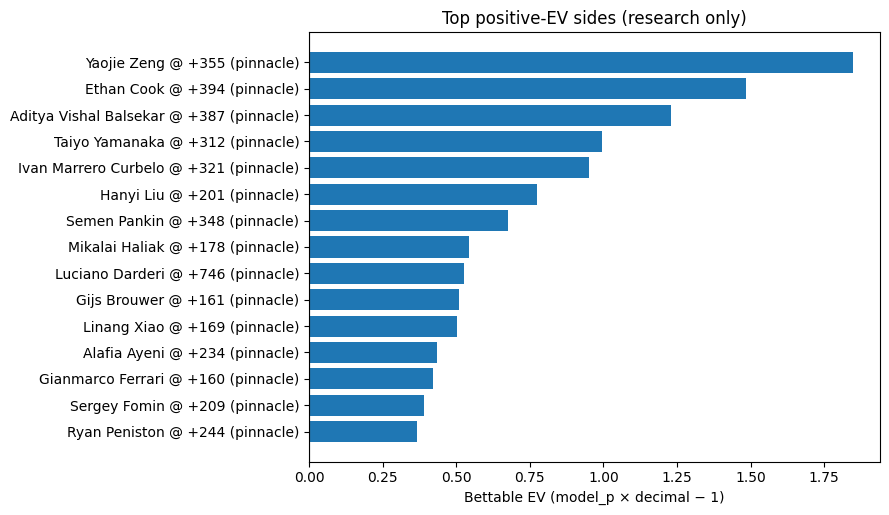

In [5]:
if board.empty:
    print("Nothing to plot.")
else:
    top = board.head(15).iloc[::-1]
    labels = [
        f"{row.player} @ {row.american:+.0f} ({row.bookmaker})"
        for row in top.itertuples()
    ]
    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.35 * len(top))))
    ax.barh(labels, top["ev"].to_numpy())
    ax.axvline(0.0, color="0.4", linewidth=0.8)
    ax.set_xlabel("Bettable EV (model_p × decimal − 1)")
    ax.set_title("Top positive-EV sides (research only)")
    fig.tight_layout()
    plt.show()
